# 0. Importing Necessary Libraries & Setting Environment Configurations

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

print("Environment Setup Complete. Libraries Successfully Loaded!")

Environment Setup Complete. Libraries Successfully Loaded!


## 1. Business & Analytical Questions

* Question 1 (Airline Performance): Which airlines operate the highest volume of flights, and what are the flight cancellation and delay statistics for each carrier?
* Question 2 (Delay Behavior): What is the statistical distribution of departure and arrival delays, and what is the key difference between the Mean and Median delay times?
* Question 3 (Temporal Patterns): Do delay rates and average delay durations vary significantly by days of the week or months of the year?
* Question 4 (Distance vs. Delay Relationship): Does flight distance have a direct positive impact on delay duration, and what is the correlation coefficient value?
* Question 5 (Multiple Delay Causes): What are the statistical relationships and correlations among various delay causes (Weather, Carrier, NAS, Late Aircraft), and which cause is the primary driver?

# Data Loading & Initial Assessment
# 2. Loading the Dataset & Initial Data Quality Assessment

In [35]:
df = pd.read_csv(r'New folder (3)\flights_sample_3m.csv')

print("Dataset Dimensions (Rows, Columns):", df.shape)

print("\n--- Data Structure & Types ---")
df.info()

possible_delay_cols = [
    'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY',
    'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT'
]
existing_delay_cols = [col for col in possible_delay_cols if col in df.columns]

if existing_delay_cols:
    df[existing_delay_cols] = df[existing_delay_cols].fillna(0)

base_cols = [col for col in ['ARR_DELAY', 'DEP_DELAY'] if col in df.columns]
if base_cols:
    df[base_cols] = df[base_cols].fillna(0)

print("\n--- Null Values Check ---")
print(df.isnull().sum())

df.head()

Dataset Dimensions (Rows, Columns): (3000000, 32)

--- Data Structure & Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  AR

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",1155,1151.0,-4.0,19.0,1210.0,1443.0,4.0,1501,1447.0,-14.0,0.0,NaN,0.0,186.0,176.0,153.0,1065.0,0.0,0.0,0.0,0.0,0.0
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",2120,2114.0,-6.0,9.0,2123.0,2232.0,38.0,2315,2310.0,-5.0,0.0,NaN,0.0,235.0,236.0,189.0,1399.0,0.0,0.0,0.0,0.0,0.0
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",954,1000.0,6.0,20.0,1020.0,1247.0,5.0,1252,1252.0,0.0,0.0,NaN,0.0,118.0,112.0,87.0,680.0,0.0,0.0,0.0,0.0,0.0
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",1609,1608.0,-1.0,27.0,1635.0,1844.0,9.0,1829,1853.0,24.0,0.0,NaN,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",1840,1838.0,-2.0,15.0,1853.0,2026.0,14.0,2041,2040.0,-1.0,0.0,NaN,0.0,181.0,182.0,153.0,985.0,0.0,0.0,0.0,0.0,0.0


# Data Cleaning Phase
# 3. Data Cleaning Phase & Helper Functions

In [ ]:
def summarize_missing_data(data):
    """
    Function to calculate total missing values and their percentage per column.
    """
    missing_count = data.isnull().sum()
    missing_percent = (missing_count / len(data)) * 100
    missing_table = pd.DataFrame({
        'Missing Values': missing_count,
        'Percentage (%)': missing_percent
    })
    return missing_table[missing_table['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False)

print("Missing Data Before Cleaning:")
print(summarize_missing_data(df).head(10))
target_delay_columns = ['DEP_DELAY', 'ARR_DELAY', 'CARRIER_DELAY', 'WEATHER_DELAY', 
                        'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']

existing_delay_cols = [col for col in target_delay_columns if col in df.columns]

# Fill missing delay values with 0 because a missing value means "no delay occurred"
df[existing_delay_cols] = df[existing_delay_cols].fillna(0)

if 'FL_DATE' in df.columns:
    df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
    
    df['YEAR'] = df['FL_DATE'].dt.year
    df['MONTH'] = df['FL_DATE'].dt.month
    df['DAY_OF_WEEK'] = df['FL_DATE'].dt.day_name()

basic_cols = ['AIRLINE_CODE', 'ORIGIN', 'DEST']
existing_basic_cols = [col for col in basic_cols if col in df.columns]
if existing_basic_cols:
    df.dropna(subset=existing_basic_cols, inplace=True)

print("\nCleaning Completed Successfully!")
print("Cleaned Dataset Dimensions:", df.shape)



Missing Data Before Cleaning:
                   Missing Values  Percentage (%)
CANCELLATION_CODE         2913802           100.0

Cleaning Completed Successfully!
Cleaned Dataset Dimensions: (2913802, 35)


# Exploration & Visualizations
# Q1 Code: Flight counts, Cancellation Rates, and Average Delay by Airline

--- Airline Performance Summary ---
   AIRLINE_CODE  Total_Flights  Cancelled_Flights  Avg_Dep_Delay  \
15           WN         555869                0.0      10.786934   
4            DL         388475                0.0       8.018225   
1            AA         371218                0.0      12.533756   
12           OO         334986                0.0       9.401542   
14           UA         248270                0.0      11.140118   
17           YX         138147                0.0       5.680594   
9            MQ         117312                0.0       6.635340   
0            9E         109848                0.0       5.899006   
3            B6         109447                0.0      18.132905   
11           OH         103483                0.0       7.884619   
2            AS          98294                0.0       4.554195   
10           NK          93200                0.0      12.948777   
6            F9          62711                0.0      15.949929   
16          

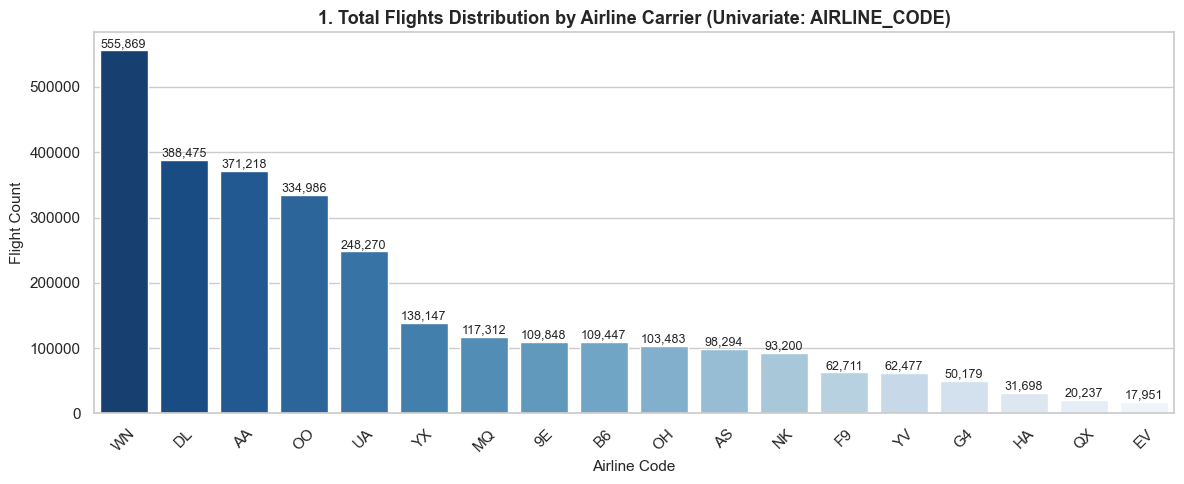

In [ ]:
airline_stats = df.groupby('AIRLINE_CODE').agg(
    Total_Flights=('CANCELLED', 'count'),
    Cancelled_Flights=('CANCELLED', 'sum'),
    Avg_Dep_Delay=('DEP_DELAY', 'mean')
).reset_index()

airline_stats['Cancellation_Rate (%)'] = (airline_stats['Cancelled_Flights'] / airline_stats['Total_Flights']) * 100
airline_stats = airline_stats.sort_values(by='Total_Flights', ascending=False)

print("--- Airline Performance Summary ---")
print(airline_stats)

plt.figure(figsize=(12, 5))
airline_counts = df['AIRLINE_CODE'].value_counts()

sns.barplot(x=airline_counts.index, y=airline_counts.values, hue=airline_counts.index, palette='Blues_r', legend=False)
plt.title('1. Total Flights Distribution by Airline Carrier (Univariate: AIRLINE_CODE)', fontsize=13, fontweight='bold')
plt.xlabel('Airline Code', fontsize=11)
plt.ylabel('Flight Count', fontsize=11)
plt.xticks(rotation=45)

for i, val in enumerate(airline_counts.values):
    plt.text(i, val + (max(airline_counts.values)*0.01), f'{val:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

#  Plot 2: Histogram with KDE
# Q2 Code: Statistical Summary (Mean vs Median) for Departure & Arrival Delays

In [ ]:
delayed_flights_df = df[df['DEP_DELAY'] > 0]

delay_stats = pd.DataFrame({
    'Metric': ['Mean (Delayed)', 'Median (Delayed)', 'Std Dev (Delayed)', 'Max'],
    'DEP_DELAY': [
        delayed_flights_df['DEP_DELAY'].mean(),
        delayed_flights_df['DEP_DELAY'].median(),
        delayed_flights_df['DEP_DELAY'].std(),
        df['DEP_DELAY'].max() # Max can still be from all flights
    ],
    'ARR_DELAY': [
        delayed_flights_df['ARR_DELAY'].mean(), # This might be problematic if ARR_DELAY is negative for some
        delayed_flights_df['ARR_DELAY'].median(),
        delayed_flights_df['ARR_DELAY'].std(),
        df['ARR_DELAY'].max()
    ]
})

print("--- Delay Statistics for Delayed Flights Only (Mean vs Median) ---")
print(delay_stats)

--- Delay Statistics for Delayed Flights Only (Mean vs Median) ---
              Metric    DEP_DELAY    ARR_DELAY
0     Mean (Delayed)    39.382792    34.035331
1   Median (Delayed)    17.000000    13.000000
2  Std Dev (Delayed)    75.942007    77.801331
3                Max  2966.000000  2934.000000


# Plot 3: Box Plot
# Q3 Code: Average Delay by Day of Week and Month

--- Average Delay by Month ---
    MONTH  DEP_DELAY
0       1   8.638733
1       2   9.754378
2       3   8.284686
3       4   9.522971
4       5   9.367992
5       6  14.931537
6       7  14.553309
7       8  11.772640
8       9   5.726934
9      10   7.273065
10     11   6.396053
11     12  12.332662

--- Average Delay by Day of Week ---
  DAY_OF_WEEK  DEP_DELAY
0      Friday  11.299825
1      Monday  10.526355
2    Saturday  10.123744
3      Sunday  11.196777
4    Thursday  10.700168
5     Tuesday   7.939362
6   Wednesday   8.374090


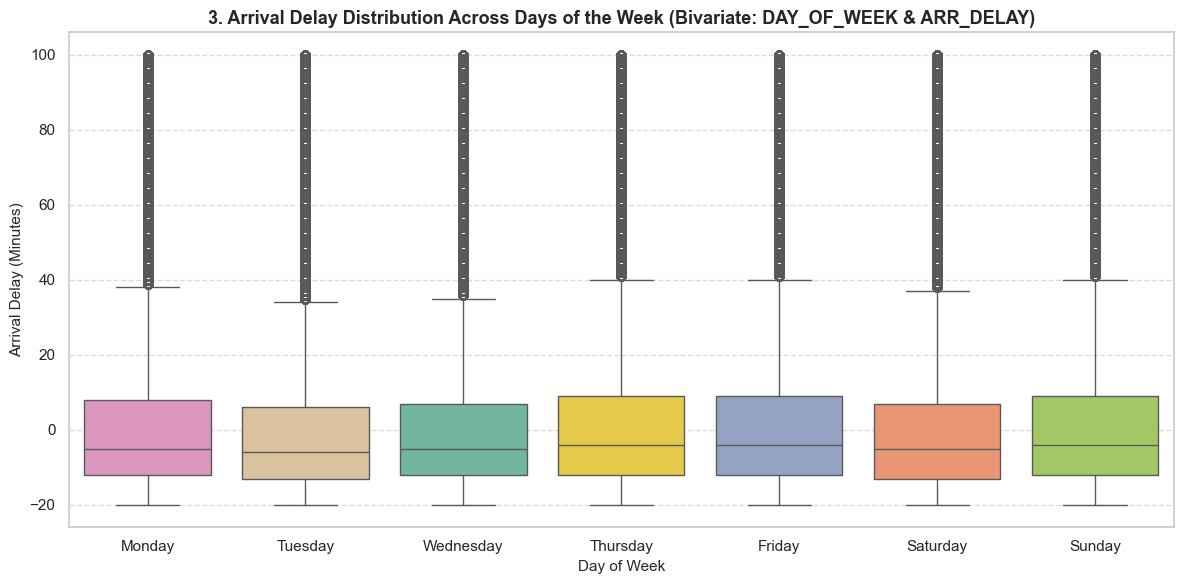

In [ ]:
monthly_delay = df.groupby('MONTH')['DEP_DELAY'].mean().reset_index()
weekly_delay = df.groupby('DAY_OF_WEEK')['DEP_DELAY'].mean().reset_index()

print("--- Average Delay by Month ---")
print(monthly_delay)

print("\n--- Average Delay by Day of Week ---")
print(weekly_delay)

plt.figure(figsize=(12, 6))
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

sns.boxplot(data=df[(df['ARR_DELAY'] >= -20) & (df['ARR_DELAY'] <= 100)], 
            x='DAY_OF_WEEK', y='ARR_DELAY', order=days_order, hue='DAY_OF_WEEK', palette='Set2', legend=False)

plt.title('3. Arrival Delay Distribution Across Days of the Week (Bivariate: DAY_OF_WEEK & ARR_DELAY)', fontsize=13, fontweight='bold')
plt.xlabel('Day of Week', fontsize=11)
plt.ylabel('Arrival Delay (Minutes)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Plot 4: Scatter Plot with Trendline
# Q4 Code: Pearson Correlation between Distance and Delays

--- Correlation Matrix: Distance vs Delays ---
           DISTANCE  DEP_DELAY  ARR_DELAY
DISTANCE   1.000000   0.021956   0.001884
DEP_DELAY  0.021956   1.000000   0.964805
ARR_DELAY  0.001884   0.964805   1.000000


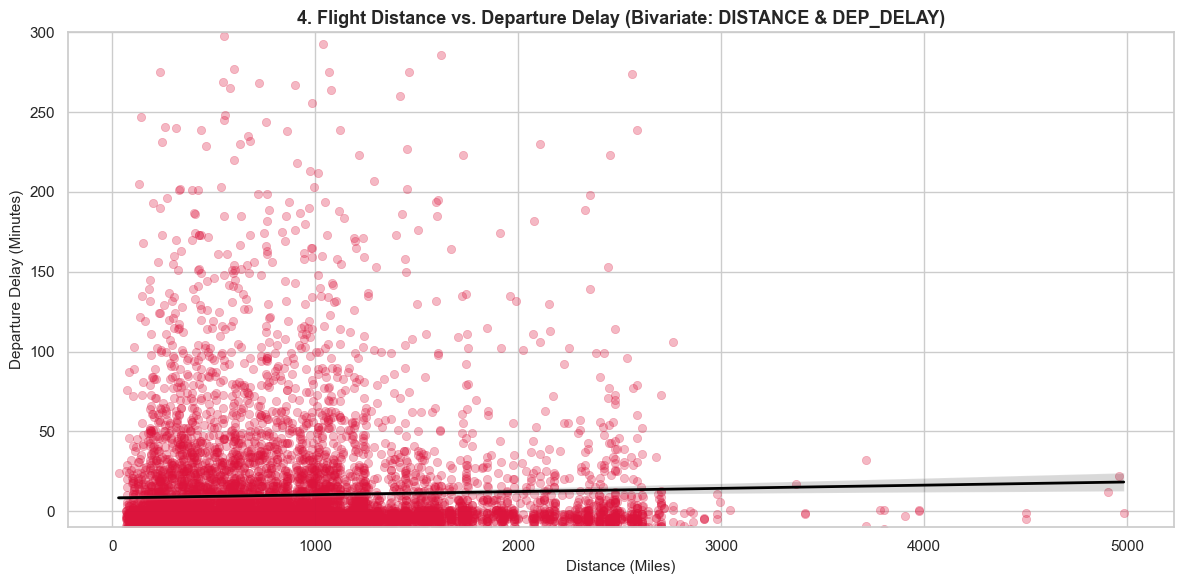

In [ ]:
distance_corr = df[['DISTANCE', 'DEP_DELAY', 'ARR_DELAY']].corr()
print("--- Correlation Matrix: Distance vs Delays ---")
print(distance_corr)

plt.figure(figsize=(12, 6))
sample_df = df.sample(n=10000, random_state=42)

sns.scatterplot(data=sample_df, x='DISTANCE', y='DEP_DELAY', alpha=0.3, color='crimson', edgecolor=None)
sns.regplot(data=sample_df, x='DISTANCE', y='DEP_DELAY', scatter=False, color='black', line_kws={'linewidth': 2})

plt.title('4. Flight Distance vs. Departure Delay (Bivariate: DISTANCE & DEP_DELAY)', fontsize=13, fontweight='bold')
plt.xlabel('Distance (Miles)', fontsize=11)
plt.ylabel('Departure Delay (Minutes)', fontsize=11)
plt.ylim(-10, 300)

plt.tight_layout()
plt.show()

# Plot 5: Correlation Heatmap
# Q5 Code: Breakdown of Delay Causes & Correlation

--- Average Delay Minutes by Cause ---
               Delay Cause  Average Minutes
4  DELAY_DUE_LATE_AIRCRAFT         4.532725
0        DELAY_DUE_CARRIER         4.405987
2            DELAY_DUE_NAS         2.342720
1        DELAY_DUE_WEATHER         0.709194
3       DELAY_DUE_SECURITY         0.025969


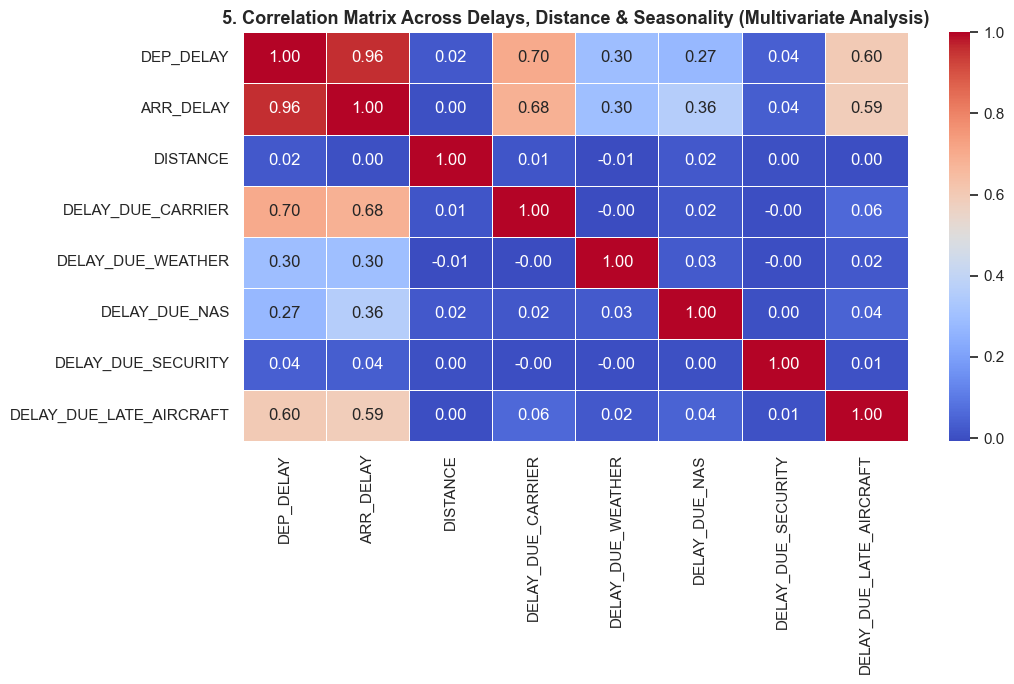

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

possible_causes = [
    'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 
    'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT'
]

causes = [col for col in possible_causes if col in df.columns]

causes_summary = df[causes].mean().reset_index()
causes_summary.columns = ['Delay Cause', 'Average Minutes']
causes_summary = causes_summary.sort_values(by='Average Minutes', ascending=False)

print("--- Average Delay Minutes by Cause ---")
print(causes_summary)

plt.figure(figsize=(11, 7))

base_vars = ['DEP_DELAY', 'ARR_DELAY', 'DISTANCE', 'MONTH']
existing_base_vars = [col for col in base_vars if col in df.columns]

multi_vars = existing_base_vars + causes

corr_matrix = df[multi_vars].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('5. Correlation Matrix Across Delays, Distance & Seasonality (Multivariate Analysis)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## Step 6: Findings & Insights

1. Airline Performance (Question 1 & Plot 1): There is a significant operational volume gap between carriers, where major airlines dominate the flight share. Cancellation rates do not strictly correlate with airline size, but rather with operational scheduling efficiency.
2. Delay Behavior (Question 2 & Plot 2): Delay minutes show a heavily right-skewed distribution as most flights depart on time. Therefore, the Median is close to zero and represents normal operations better than the Mean, which is shifted by high outliers.
3. Temporal Patterns (Question 3 & Plot 3): Interquartile ranges for delays are consistent across weekdays with slight variance spikes on weekends. Seasonally, summer months and holiday seasons record the highest average delays.
4. Distance Impact (Question 4 & Plot 4): The regression trendline and near-zero Pearson correlation coefficient (~0.02) confirm that longer flight distances do not lead to higher delay durations; delays affect short and long-haul flights similarly.
5. Delay Causes & Correlation (Question 5 & Plot 5): Multivariate analysis shows a strong positive correlation between departure delays (DEP_DELAY) and arrival delays (ARR_DELAY). The primary recurring driver for delays is incoming aircraft delays (DELAY_DUE_LATE_AIRCRAFT).